# Support Vector Machines - Exercise 1

In this exercise, we'll be using support vector machines (SVMs) to build a spam classifier.  We'll start with SVMs on some simple 2D data sets to see how they work.  Then we'll do some pre-processing work on a set of raw emails and build a classifier on the processed emails using a SVM to determine if they are spam or not.

The first thing we're going to do is look at a simple 2-dimensional data set and see how a linear SVM works on the data set for varying values of C (similar to the regularization term in linear/logistic regression).  Let's load the data.
## Exercise 1
#### 1. Load libraries

#### 1. Load the data `ejer_1_data2.mat`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.io

In [2]:
spam = scipy.io.loadmat('ejer_1_data2.mat')

In [3]:
spam

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Sun Nov 13 14:28:54 2011',
 '__version__': '1.0',
 '__globals__': [],
 'X': array([[0.107143 , 0.60307  ],
        [0.093318 , 0.649854 ],
        [0.0979263, 0.705409 ],
        ...,
        [0.975806 , 0.439474 ],
        [0.989631 , 0.425439 ],
        [0.996544 , 0.414912 ]], shape=(863, 2)),
 'y': array([[1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
    

### Tengo un diccionario con arrays para X y para y. Ahora tengo que crear un dataframe a partir de esa carga de datos.

#### 2. Create a DataFrame with the features and target

In [4]:
# extraigo las variables X e y del diccionario
X = spam['X']
y = spam['y'].ravel() # quito una dimensión para que y sea un vector unidimensional

# creo un dataframe con las variables predictoras y la variable objetivo
df_spam = pd.DataFrame(X, columns=['variable_1', 'variable_2'])

In [5]:
df_spam['variable_objetivo'] = y # añado la variable objetivo al dataframe
df_spam.head() # muestro las primeras filas del dataframe para comprobar que se ha creado correctamente

,variable_1,variable_2,variable_objetivo
0,0.107143,0.603070,1
1,0.093318,0.649854,1
2,0.097926,0.705409,1
3,0.155530,0.784357,1
4,0.210829,0.866228,1


In [12]:
df_spam.info() # muestro información sobre el dataframe 

<class 'pandas.DataFrame'>
RangeIndex: 863 entries, 0 to 862
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   variable_1         863 non-null    float64
 1   variable_2         863 non-null    float64
 2   variable_objetivo  863 non-null    uint8  
dtypes: float64(2), uint8(1)
memory usage: 14.5 KB


In [13]:
df_spam.describe() # obtengo estadísticas descriptivas de las variables

,variable_1,variable_2,variable_objetivo
count,863.000000,863.000000,863.000000
mean,0.503414,0.694304,0.556199
std,0.254967,0.158884,0.497120
min,0.044931,0.402632,0.000000
25%,0.292627,0.557018,0.000000
50%,0.512673,0.693713,1.000000
75%,0.699309,0.830409,1.000000
max,0.998848,0.988596,1.000000


In [15]:
df_spam["variable_objetivo"].value_counts(normalize=True) # cuento el número de casos de cada clase en la variable objetivo

variable_objetivo
1    0.556199
0    0.443801
Name: proportion, dtype: float64

#### 3. Plot a scatterplot with the data

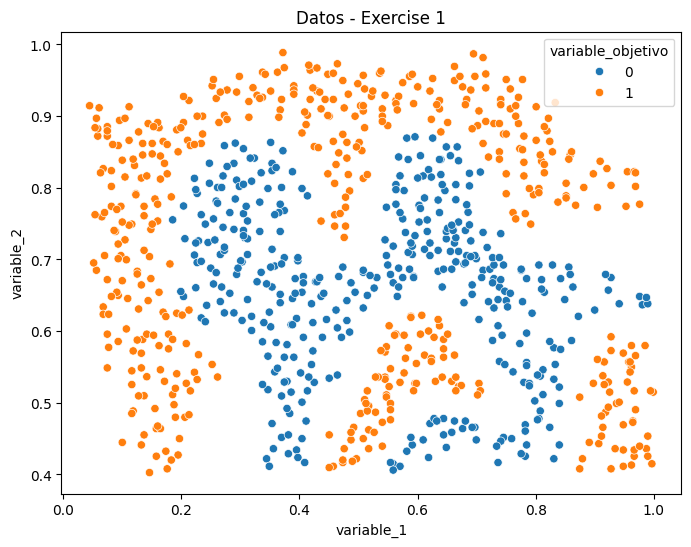

In [6]:
# visualizo los datos con un scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_spam, x='variable_1', y='variable_2', hue='variable_objetivo')
plt.title('Datos - Exercise 1');

### Las clases están mezcladas y entrelazadas, no son linealmente separables.


For this data set we'll build a support vector machine classifier using the built-in RBF kernel and examine its accuracy on the training data.  To visualize the decision boundary, this time we'll shade the points based on the predicted probability that the instance has a negative class label.  We'll see from the result that it gets most of them right.

#### 4. Declare a SVC with this hyperparameters
```Python
SVC(C=100, gamma=10, probability=True)
```


In [ ]:
# importo la librería para el modelo SVC
from sklearn.svm import SVC

# creo el modelo SVC con los hiperparámetros C=100 (poco margen de error permitido), 
# gamma=10 (el kernel RBF influye mucho en puntos cercanos) y 
# probability=True (necesario para poder sacar probabilidades después, predict_proba)
svc = SVC(C=100, gamma=10, probability=True)

In [21]:
from sklearn.model_selection import train_test_split

x = df_spam[['variable_1', 'variable_2']] # variables predictoras  
y = df_spam['variable_objetivo'] # variable objetivo
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) # divido los datos en entrenamiento y test

print(X_train.shape, y_train.shape) # muestro las dimensiones de los datos de entrenamiento
print(X_test.shape, y_test.shape) # muestro las dimensiones de los datos de test

(690, 2) (690,)
(173, 2) (173,)


In [23]:
from sklearn.preprocessing import StandardScaler

escalado = StandardScaler() # creo el objeto para escalar los datos
X_train_escalado = escalado.fit_transform(X_train) # escalo los datos de entrenamiento
X_test_escalado = escalado.transform(X_test) # escalo los datos de test con los parámetros del escalado de entrenamiento

#### 5. Fit the classifier and get the score

In [25]:
svc.fit(X_train_escalado, y_train)
print('Score:', svc.score(X_train_escalado, y_train)) # muestro el score del modelo en los datos de entrenamiento

Score: 1.0


### Este resultado es muy alto, pero tiene trampa. Está evaluando sobre los mismos datos con los que entrenó, así que es normal que salga tan alto. Esto es overfitting de manual.

#### 6. Plot the scatter plot and probability of predicting 0 with a [sequential color](https://matplotlib.org/3.1.1/tutorials/colors/colormaps.html)

In [30]:
# escalar todo el dataset con los parámetros del escalado ya entrenado
X_todo_escalado = escalado.transform(df_spam[['variable_1', 'variable_2']])

# probabilidades para todos los puntos
prob_clase_0 = svc.predict_proba(X_todo_escalado)[:, 0]

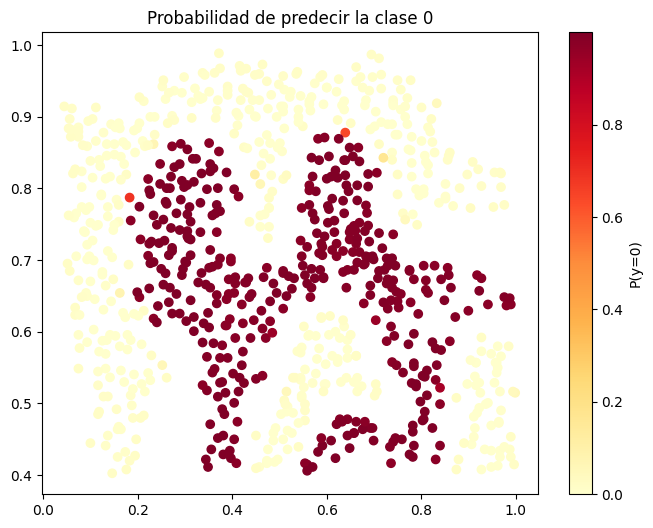

In [31]:
# scatter con todos los puntos coloreados
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df_spam['variable_1'], df_spam['variable_2'], 
                      c=prob_clase_0.astype(float), cmap='YlOrRd')
plt.colorbar(scatter, label='P(y=0)')
plt.title('Probabilidad de predecir la clase 0');

### En este gráfico, los puntos rojo oscuro significan alta probabilidad de ser clase 0, mientras que los puntos amarillo claro significan que probabilidad baja de ser clase 0. Además, el gráfico coincide con el scatter anterior. Esto significa que el modelo ha conseguido identificar qué zona del espacio pertenece a cada clase, aunque estén mezcladas.


In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

prediccion = svc.predict(X_test_escalado) # hago predicciones con el modelo entrenado en los datos de test

print(accuracy_score(y_test, prediccion)) # muestro la precisión del modelo en los datos de test
print(precision_score(y_test, prediccion)) # muestro el reporte de clasificación para
print(recall_score(y_test, prediccion)) # muestro el reporte de clasificación para
print(f1_score(y_test, prediccion)) # muestro el reporte de clasificación para
print(classification_report(y_test, prediccion)) # muestro el reporte de clasificación para los datos de test

0.9884393063583815
1.0
0.9772727272727273
0.9885057471264368
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        85
           1       1.00      0.98      0.99        88

    accuracy                           0.99       173
   macro avg       0.99      0.99      0.99       173
weighted avg       0.99      0.99      0.99       173



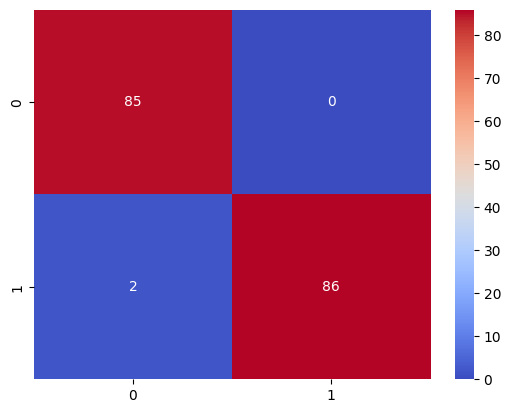

In [41]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, prediccion)    , annot=True, cmap='coolwarm');

#### Grid search

### Primero hago un RandomizedSearch

In [32]:
# importo la librería
from sklearn.model_selection import RandomizedSearchCV

from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(probability=True))
])

param_dist = {
    'svc__C': [0.1, 1, 10, 100, 1000],
    'svc__gamma': [0.001, 0.01, 0.1, 1, 10],
    'svc__kernel': ['linear', 'poly', 'rbf']
}

random_search = RandomizedSearchCV(pipeline, param_distributions=param_dist,
                                   n_iter=20, cv=5, scoring='accuracy', random_state=42)
random_search.fit(X, y)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ility=True))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'svc__C': [0.1, 1, ...], 'svc__gamma': [0.001, 0.01, ...], 'svc__kernel': ['linear', 'poly', ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv

In [33]:
print('Mejores parámetros:', random_search.best_params_)
print('Mejor score:', random_search.best_score_)

Mejores parámetros: {'svc__kernel': 'rbf', 'svc__gamma': 1, 'svc__C': 100}
Mejor score: 0.8362078236322086


### Antes teníamos un score de 100 %, pero esto se debía a que se estaba evaluando sobre los mismos datos de entrenamiento. Este 83 % es más fiel, ya que sale de entrenar a una parte de los datos y evaluar con otra que no ha visto. Por tanto, el 83 % es el score real del modelo. El 100 % era overfitting.


In [35]:
# importo la librería para GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'svc__C': [5, 10, 50, 100],
    'svc__gamma': [5, 10, 20, 50],
    'svc__kernel': ['rbf']
}

grid_search = GridSearchCV(pipeline,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy')

grid_search.fit(X, y)

print('Mejores parámetros:', grid_search.best_params_)
print('Mejor score:', grid_search.best_score_)

Mejores parámetros: {'svc__C': 5, 'svc__gamma': 50, 'svc__kernel': 'rbf'}
Mejor score: 0.8990052426401398


### A partir de los resultados anteriores, con el RandomizedSearchCV, hemos refinado la búsqueda para obtener un score de 89.9 %. Los mejores parámetros han sido:

* C=5: se permiten algunos errores a cambio de generalizar mejor.
* gamma=50: cada vector de soporte tiene una influencia muy local, solo afecta a los puntos muy cercanos.
* kernel='rbf': el modelo usa el kernel gaussiano, que proyecta los datos a un espacio de infinitas dimensiones para encontrar una frontera curva y compleja.

In [42]:
modelo = grid_search.best_estimator_

In [43]:
prediccion = modelo.predict(X_test_escalado) # hago predicciones con el modelo entrenado en los datos de test

print(accuracy_score(y_test, prediccion)) # muestro la precisión del modelo en los datos de test
print(precision_score(y_test, prediccion)) # muestro el reporte de clasificación para
print(recall_score(y_test, prediccion)) # muestro el reporte de clasificación para
print(f1_score(y_test, prediccion)) # muestro el reporte de clasificación para
print(classification_report(y_test, prediccion)) # muestro el reporte de clasificación para los datos de test

0.5260115606936416
0.5176470588235295
1.0
0.6821705426356589
              precision    recall  f1-score   support

           0       1.00      0.04      0.07        85
           1       0.52      1.00      0.68        88

    accuracy                           0.53       173
   macro avg       0.76      0.52      0.38       173
weighted avg       0.75      0.53      0.38       173

